In [33]:
import pandas as pd
df=pd.read_csv("C:\\Users\\DELL\\Downloads\\data_social_network_ads.csv")

In [34]:
df.head(5)
df.shape

(400, 5)

In [35]:
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

In [36]:
#Categorical to numerical
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Gender']=encoder.fit_transform(df['Gender'])

In [37]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    int32
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int32(1), int64(4)
memory usage: 14.2 KB


In [39]:
df.describe()

,User ID,Gender,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000,400.000000
mean,1.569154e+07,0.490000,37.655000,69742.500000,0.357500
std,7.165832e+04,0.500526,10.482877,34096.960282,0.479864
min,1.556669e+07,0.000000,18.000000,15000.000000,0.000000
25%,1.562676e+07,0.000000,29.750000,43000.000000,0.000000
50%,1.569434e+07,0.000000,37.000000,70000.000000,0.000000
75%,1.575036e+07,1.000000,46.000000,88000.000000,1.000000
max,1.581524e+07,1.000000,60.000000,150000.000000,1.000000


In [40]:
df=df.drop(columns=['User ID'])

In [41]:
df.shape

(400, 4)

In [42]:
#Removing Outliers
cols=['Age','EstimatedSalary']
for col in cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]

In [43]:
df.shape

(400, 4)

In [44]:
x=df.drop(columns=['Purchased']).values
y=df['Purchased']

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [46]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [47]:
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

<AxesSubplot:>

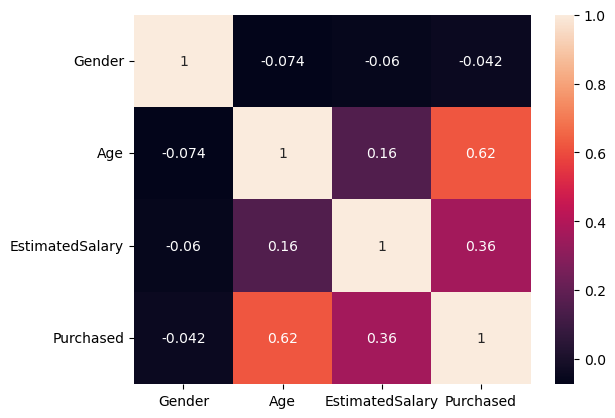

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(),annot=True)

<AxesSubplot:xlabel='Age', ylabel='Count'>

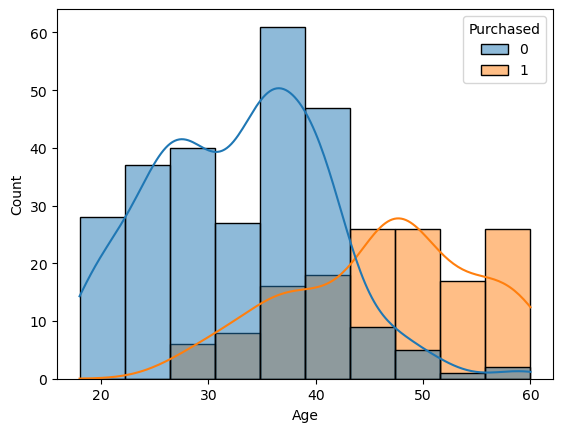

In [49]:
sns.histplot(data=df,x='Age',hue='Purchased',kde=True)

<AxesSubplot:xlabel='EstimatedSalary', ylabel='Count'>

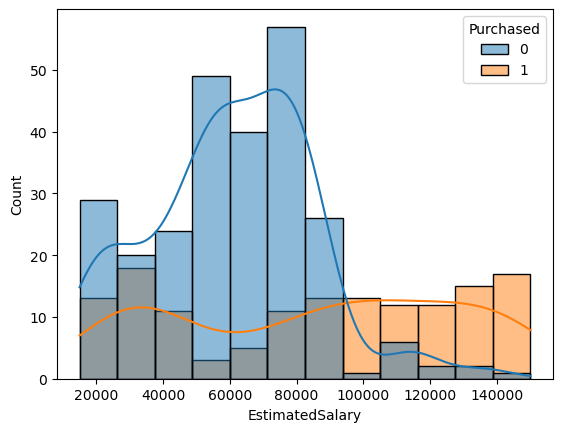

In [50]:
sns.histplot(data=df,x='EstimatedSalary',hue='Purchased',kde=True)

In [51]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

<AxesSubplot:>

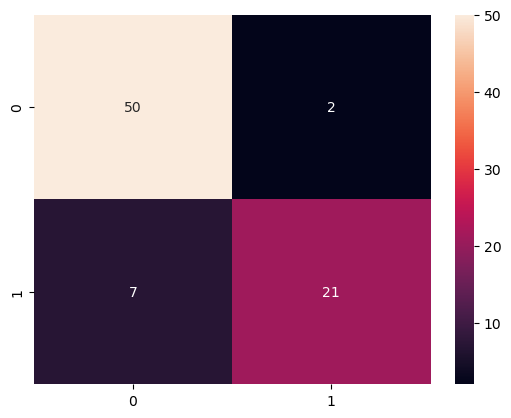

In [52]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(data=cm,annot=True)

In [53]:
print(f"Accuracy score:{accuracy_score(y_test,y_pred)}")
print(f"Recall score : {recall_score(y_test,y_pred)}")
print(f"Precision score : {precision_score(y_test,y_pred)}")
print(f"f1 score : {f1_score(y_test,y_pred)}")

Accuracy score:0.8875
Recall score : 0.75
Precision score : 0.9130434782608695
f1 score : 0.8235294117647057


In [54]:
print(f"Error rate is {1-accuracy_score(y_test,y_pred)}")

Error rate is 0.11250000000000004


In [56]:
'''
Accuracy=((TP+FP)/(TP+TN+FP+FN))
Recall=((TP)/(TP+FN))
Precision=((TP)/(TP+FP))
f1_score=((2*precision*recall)/(precison+recall))
'''

'\nAccuracy=((TP+FP)/(TP+TN+FP+FN))\nRecall=((TP)/(TP+FN))\nPrecision=((TP)/(TP+FP))\nf1_score=((2*precision*recall)/(precison+recall))\n'